In [1]:
! pip install tpot[sklearnex]

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

| Feature          | Description                                      |
|-----------------|--------------------------------------------------|
| mid             | The match ID to uniquely identify each match.    |
| date            | The date on which the match was held.           |
| venue           | The name of the stadium.                        |
| bat_team        | The batting team name.                          |
| bowl_team       | The bowling team name.                          |
| batsman         | The name of the batsman.                        |
| bowler          | The name of the bowler.                         |
| runs            | The runs scored till now.                        |
| wickets         | The wickets taken till now.                     |
| overs           | The number of overs bowled.                     |
| runs_last_5     | The number of runs scored in the last 5 overs. |
| wickets_last_5  | The number of wickets taken in the last 5 overs.|
| striker         | The batsman on the batting end.                 |
| non-striker     | The batsman on the non-striking end.            |
| total           | The total number of runs scored in the match.   |


In [3]:
df=pd.read_csv("/kaggle/input/ipl-data-2008-2017/ipl_data.csv")

In [4]:
df.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [5]:
df.shape

(76014, 15)

In [6]:
df.isnull().sum()

mid               0
date              0
venue             0
bat_team          0
bowl_team         0
batsman           0
bowler            0
runs              0
wickets           0
overs             0
runs_last_5       0
wickets_last_5    0
striker           0
non-striker       0
total             0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [8]:
df.describe()

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


In [9]:
df.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [10]:
df['date'] = pd.to_datetime(df['date'])

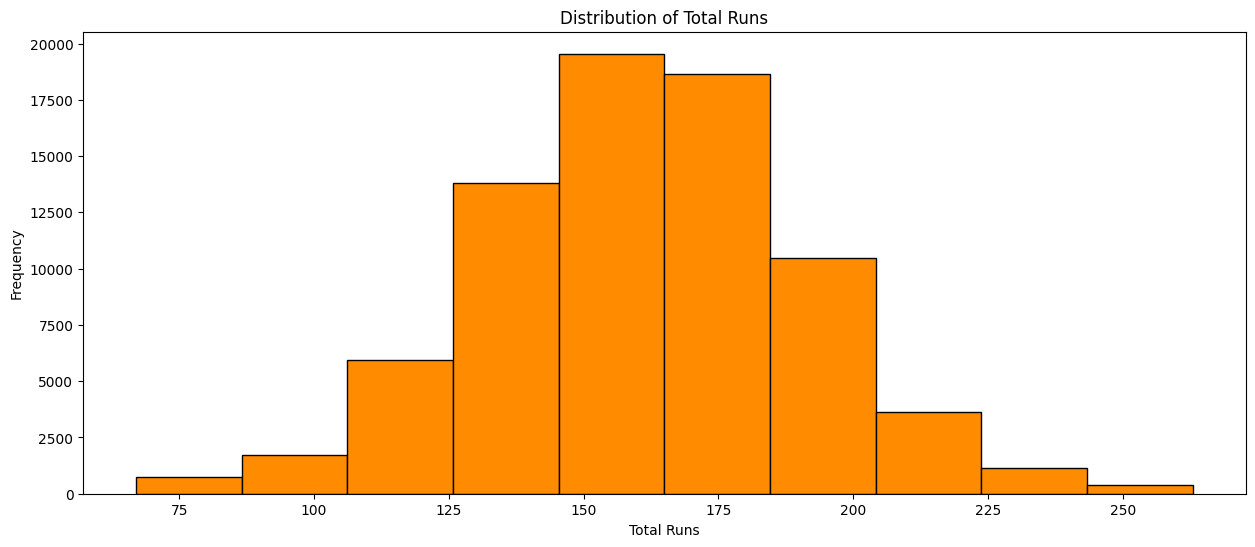

In [11]:
plt.figure(figsize=(15, 6))
plt.hist(df['total'], bins=10, edgecolor='black',color="darkorange")
plt.title('Distribution of Total Runs')
plt.xlabel('Total Runs')
plt.ylabel('Frequency')
plt.show()

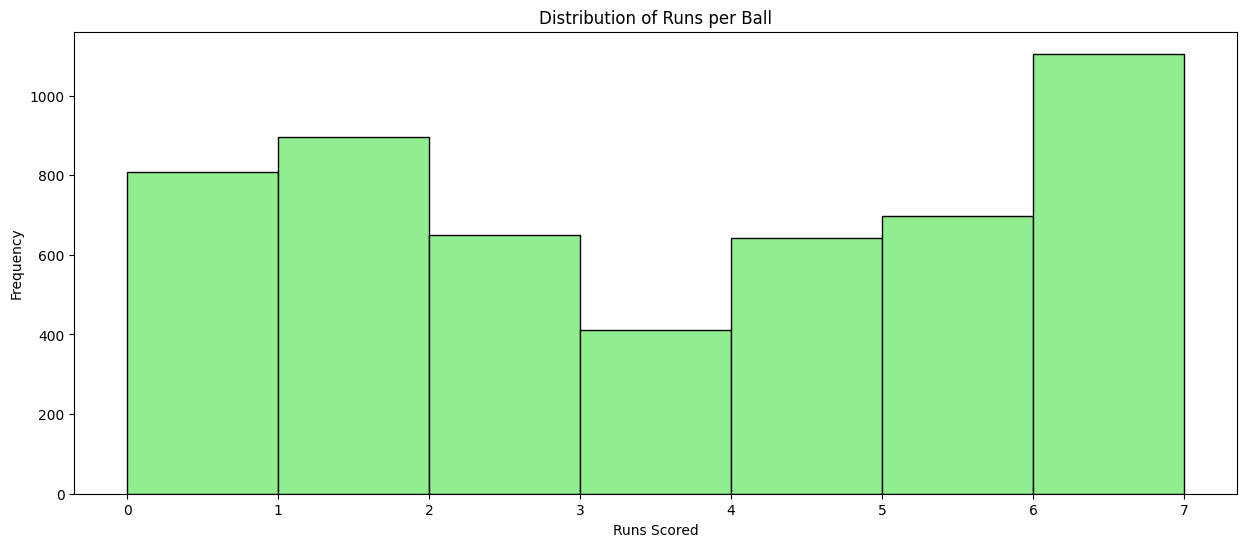

In [12]:
plt.figure(figsize=(15, 6))
plt.hist(df['runs'], bins=range(0, 8), color='lightgreen', edgecolor='black')
plt.title('Distribution of Runs per Ball')
plt.xlabel('Runs Scored')
plt.ylabel('Frequency')
plt.show()

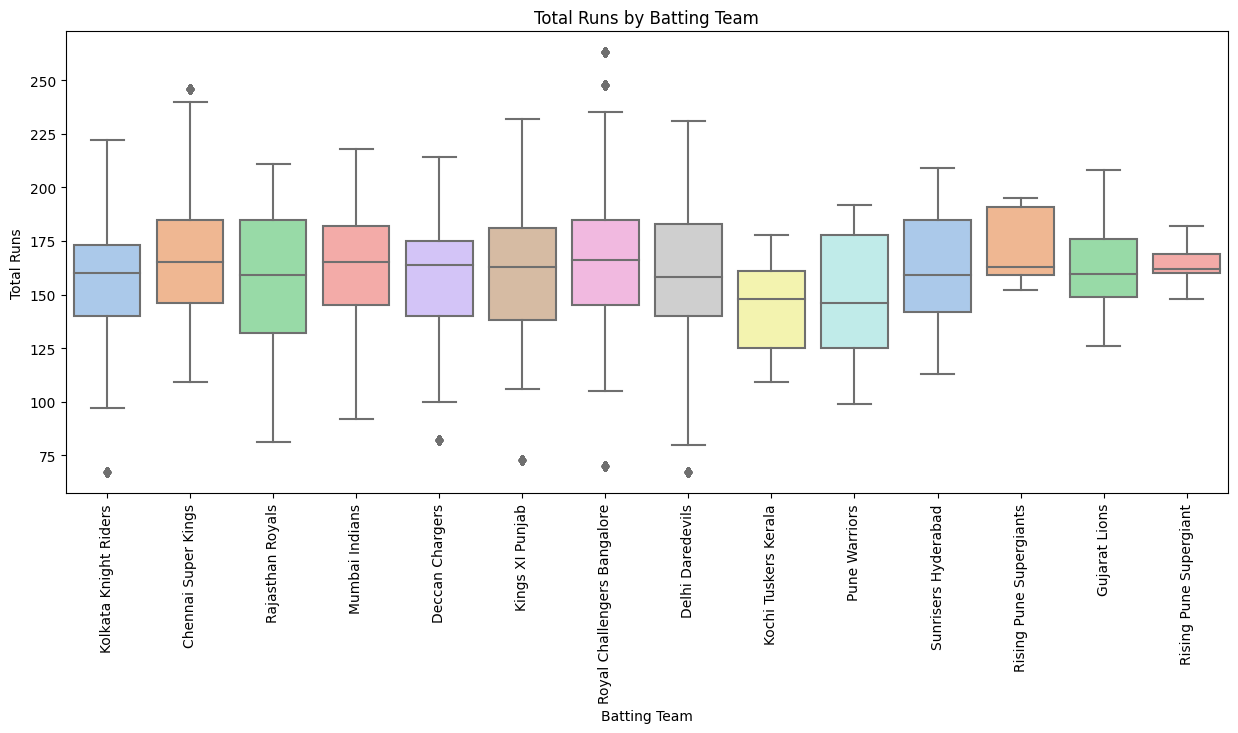

In [13]:
plt.figure(figsize=(15, 6))
sns.boxplot(x='bat_team', y='total', data=df, palette='pastel')
plt.title('Total Runs by Batting Team')
plt.xlabel('Batting Team')
plt.ylabel('Total Runs')
plt.xticks(rotation=90)
plt.show()

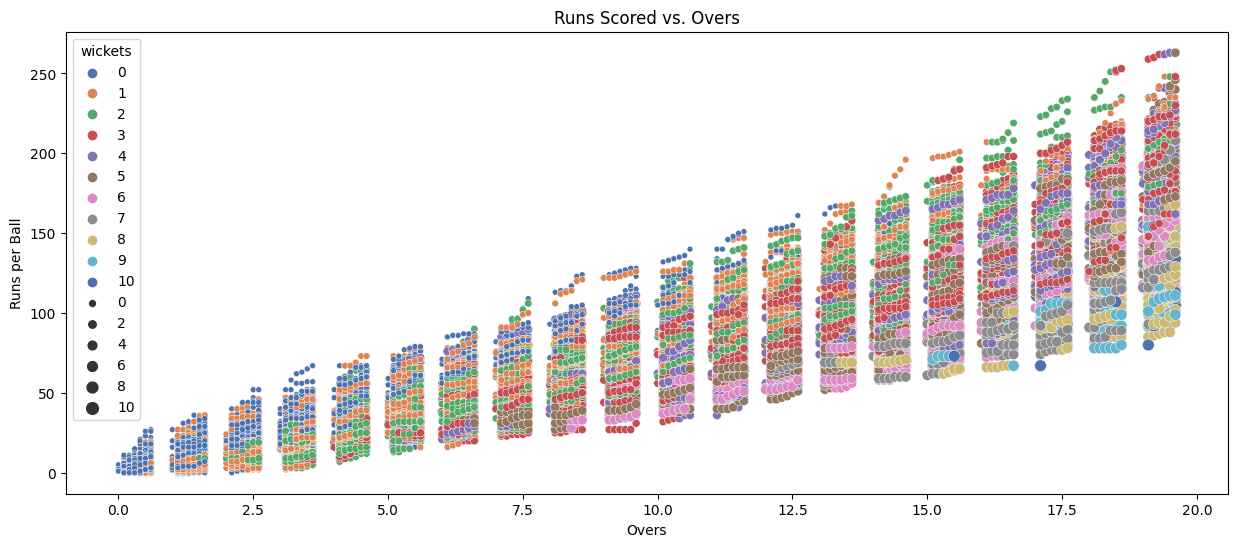

In [14]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='overs', y='runs', hue='wickets', size='wickets', data=df, palette='deep')
plt.title('Runs Scored vs. Overs')
plt.xlabel('Overs')
plt.ylabel('Runs per Ball')
plt.show()

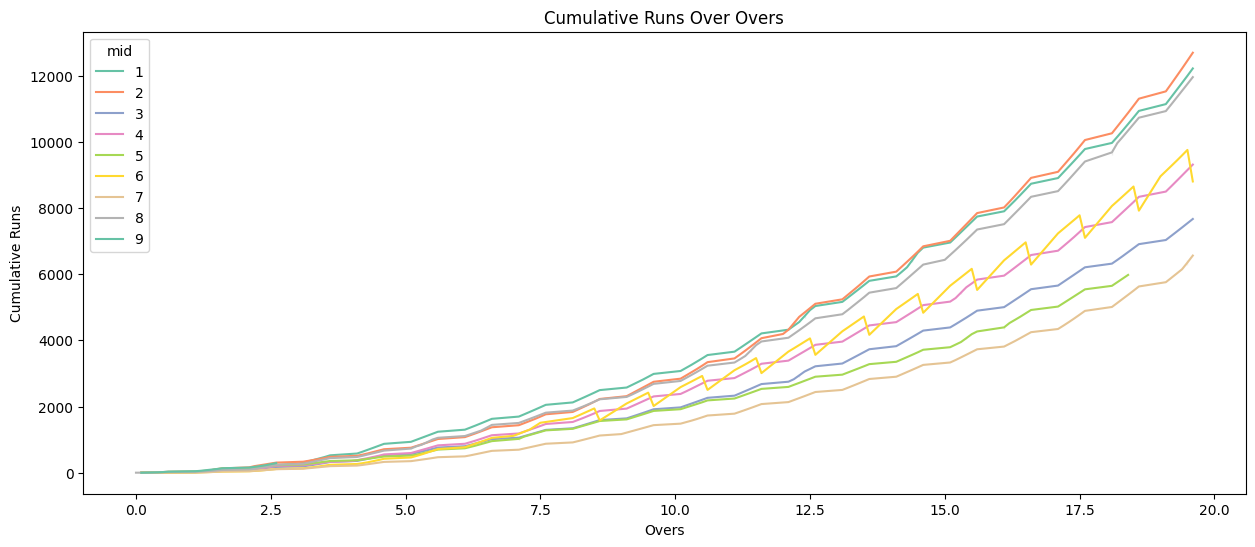

In [15]:
plt.figure(figsize=(15, 6))
df['cumulative_runs'] = df.groupby('mid')['runs'].cumsum()
sns.lineplot(x='overs', y='cumulative_runs', hue='mid', data=df[: 1000], palette='Set2')
plt.title('Cumulative Runs Over Overs')
plt.xlabel('Overs')
plt.ylabel('Cumulative Runs')
plt.show()

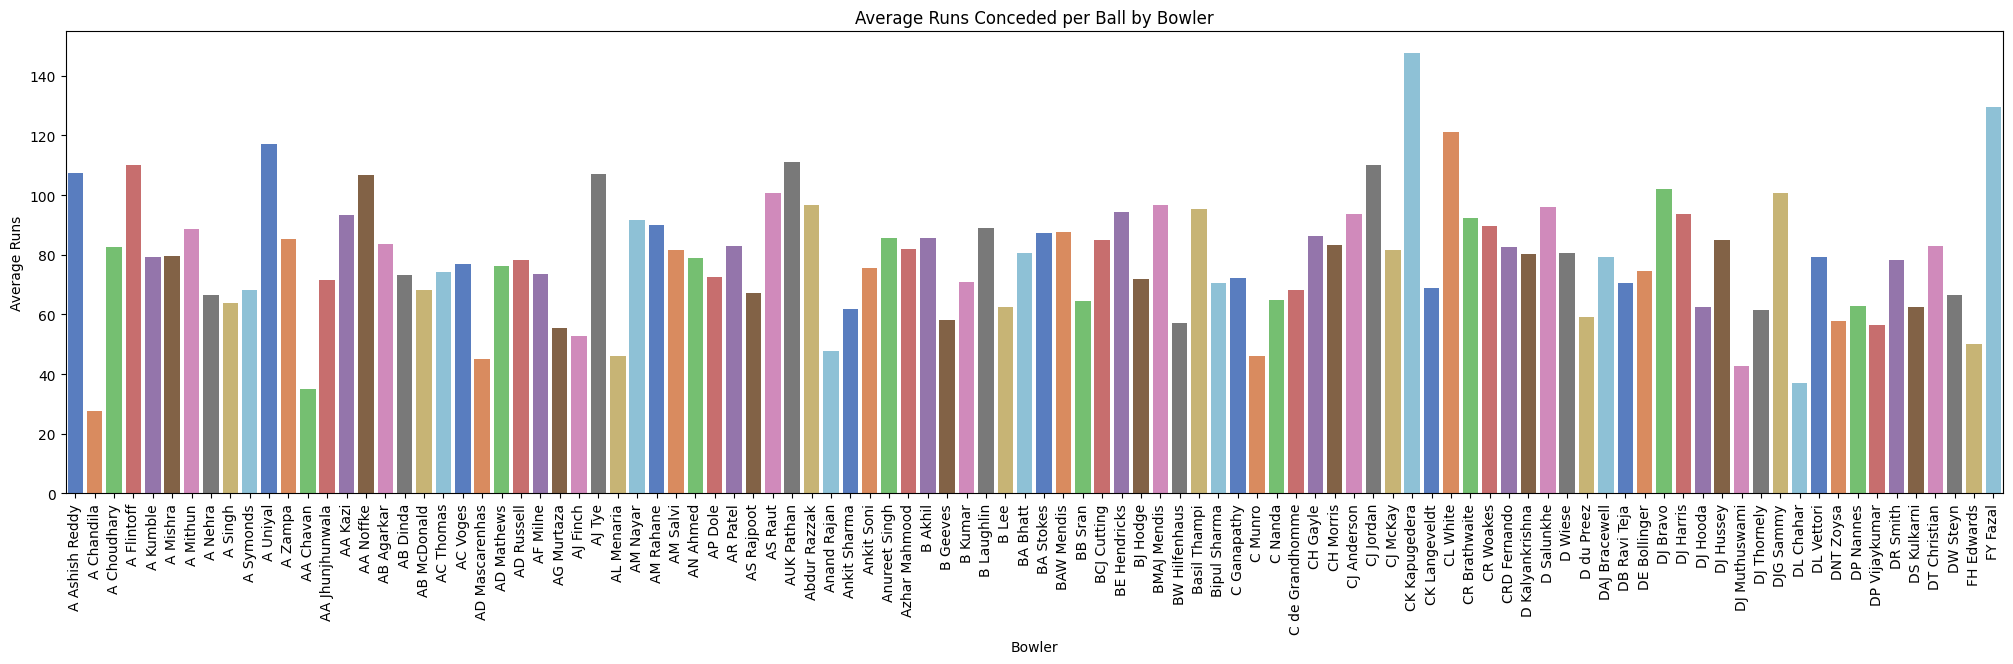

In [16]:
plt.figure(figsize=(25, 6))
avg_runs_bowler = df.groupby('bowler')['runs'].mean().reset_index()
sns.barplot(x='bowler', y='runs', data=avg_runs_bowler[: 100], palette='muted')
plt.title('Average Runs Conceded per Ball by Bowler')
plt.xlabel('Bowler')
plt.ylabel('Average Runs')
plt.xticks(rotation=90)
plt.show()

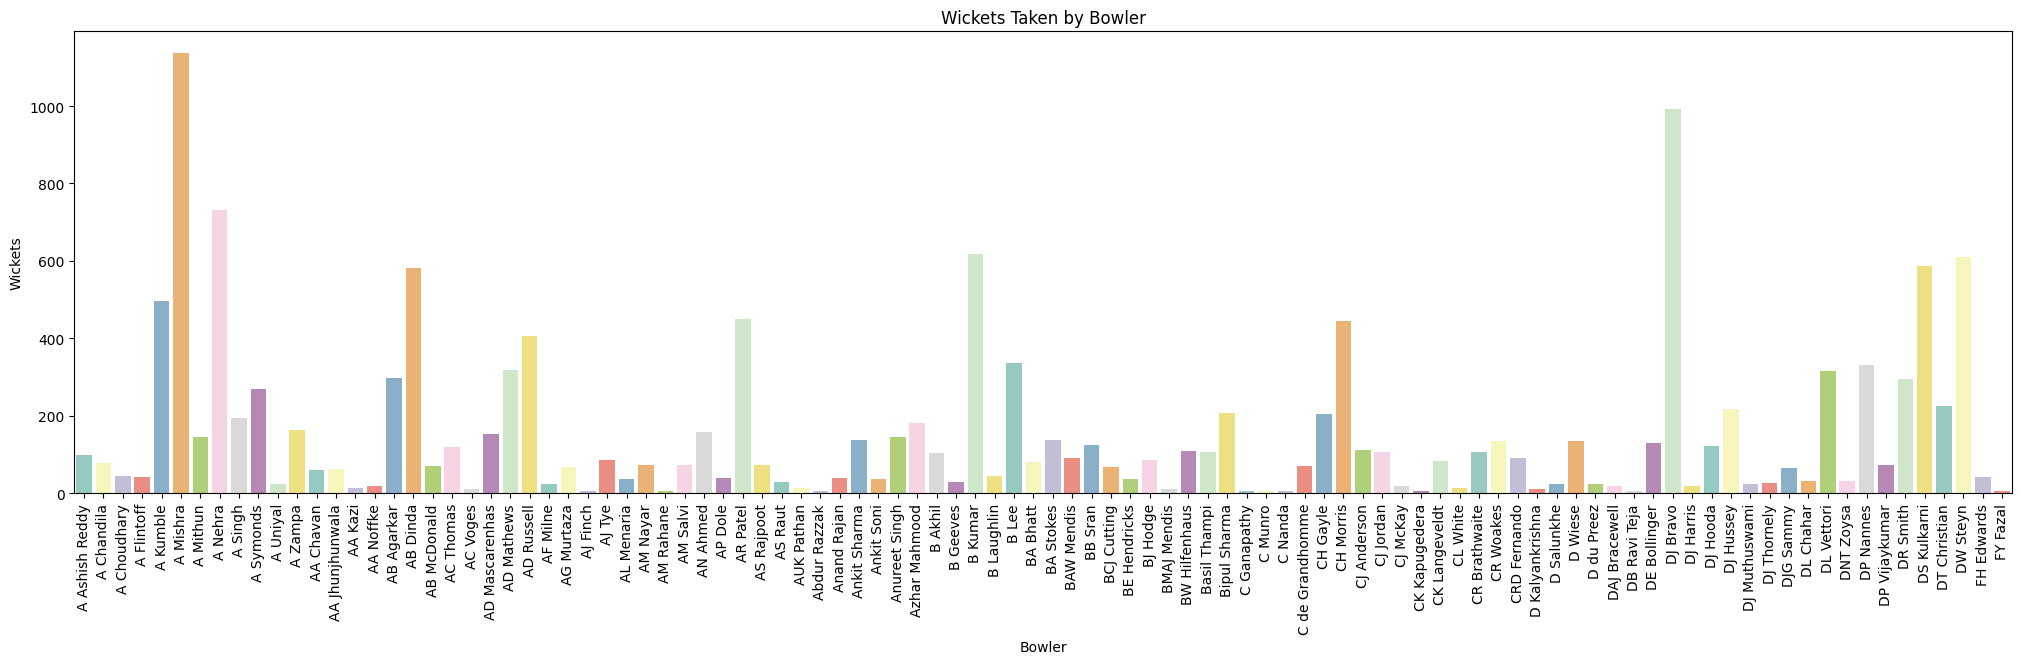

In [17]:
plt.figure(figsize=(25, 6))
wickets_bowler = df[df['wickets'] > 0].groupby('bowler')['wickets'].count().reset_index()
sns.barplot(x='bowler', y='wickets', data=wickets_bowler[: 100], palette='Set3')
plt.title('Wickets Taken by Bowler')
plt.xlabel('Bowler')
plt.ylabel('Wickets')
plt.xticks(rotation=90)
plt.show()

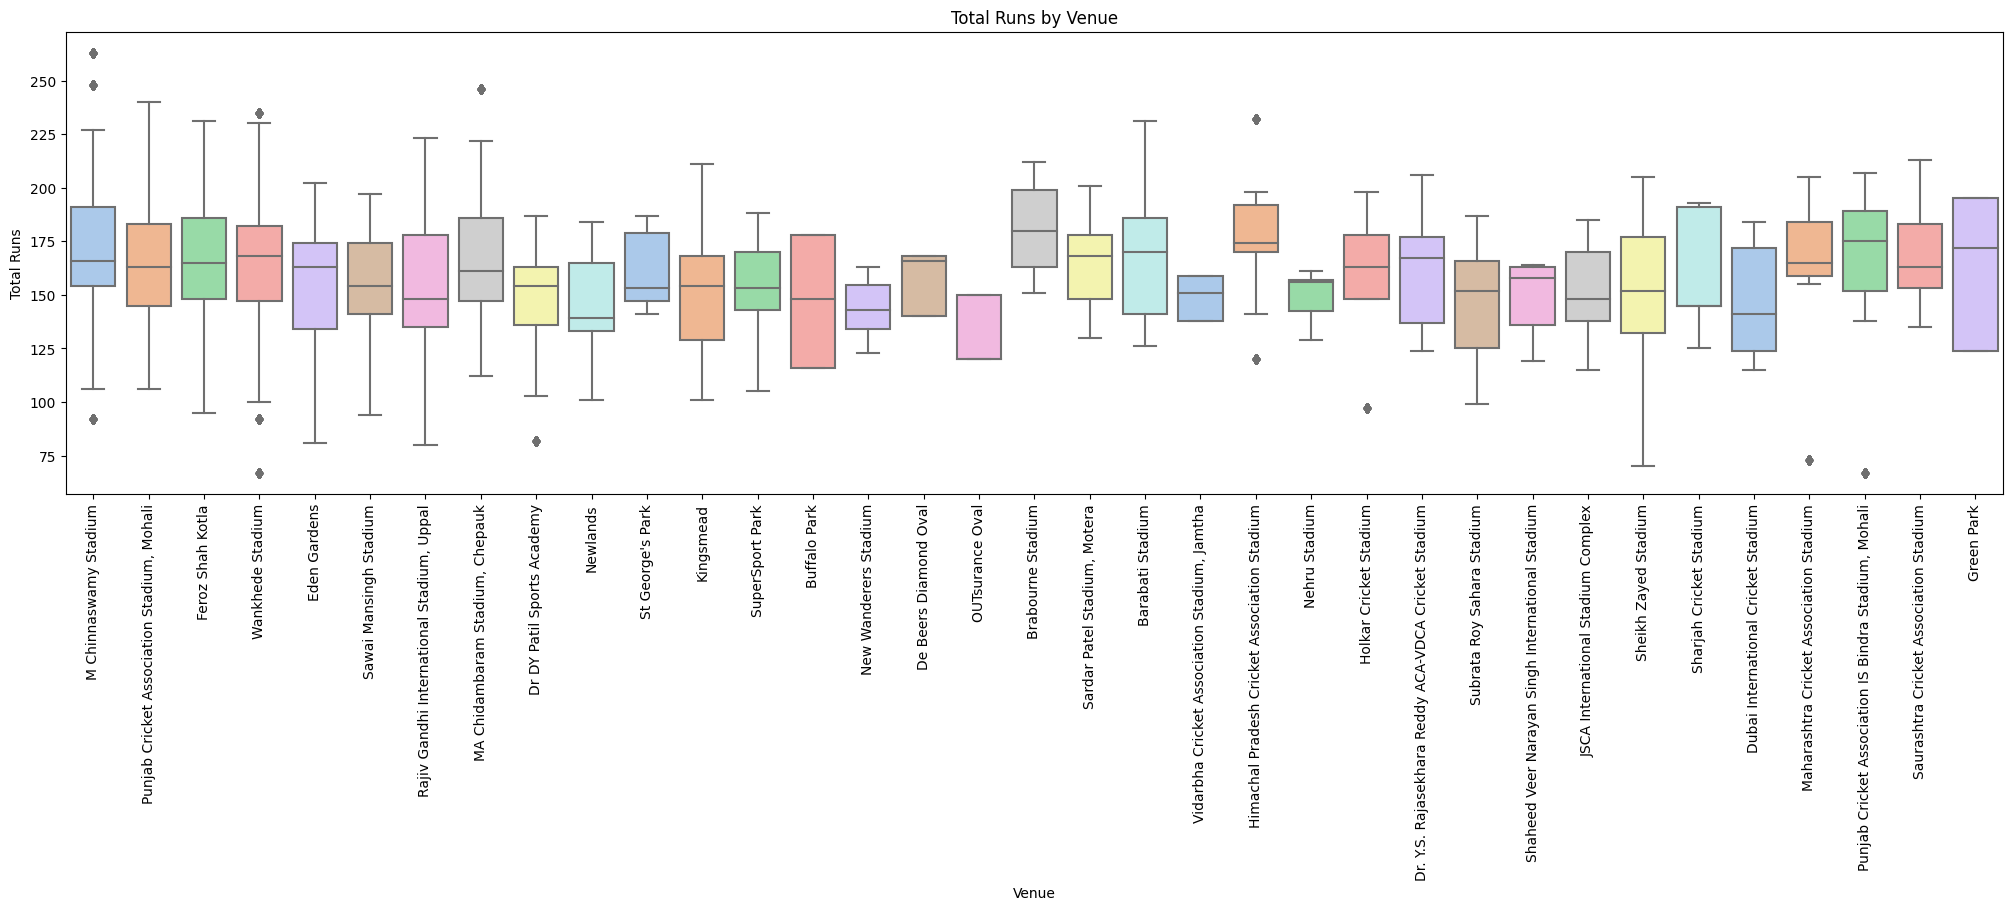

In [18]:
plt.figure(figsize=(25, 6))
sns.boxplot(x='venue', y='total', data=df, palette='pastel')
plt.title('Total Runs by Venue')
plt.xlabel('Venue')
plt.ylabel('Total Runs')
plt.xticks(rotation=90)
plt.show()

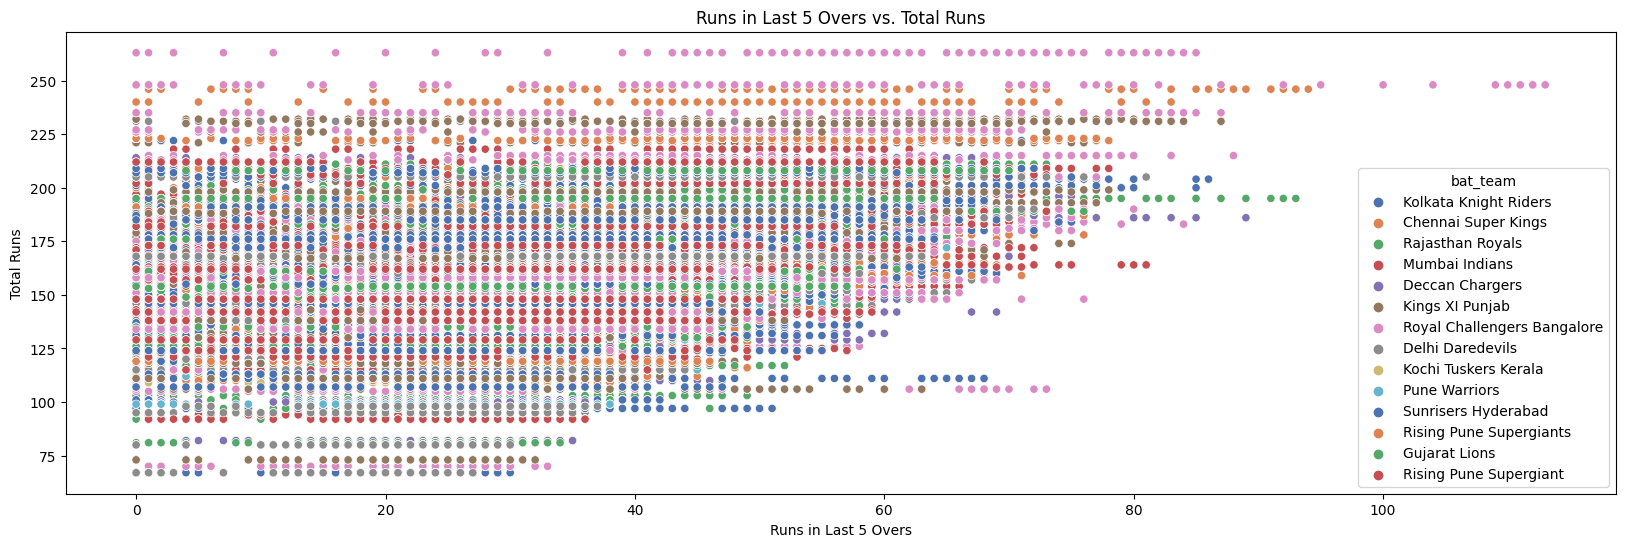

In [19]:
plt.figure(figsize=(20, 6))
sns.scatterplot(x='runs_last_5', y='total', hue='bat_team', data=df, palette='deep')
plt.title('Runs in Last 5 Overs vs. Total Runs')
plt.xlabel('Runs in Last 5 Overs')
plt.ylabel('Total Runs')
plt.show()

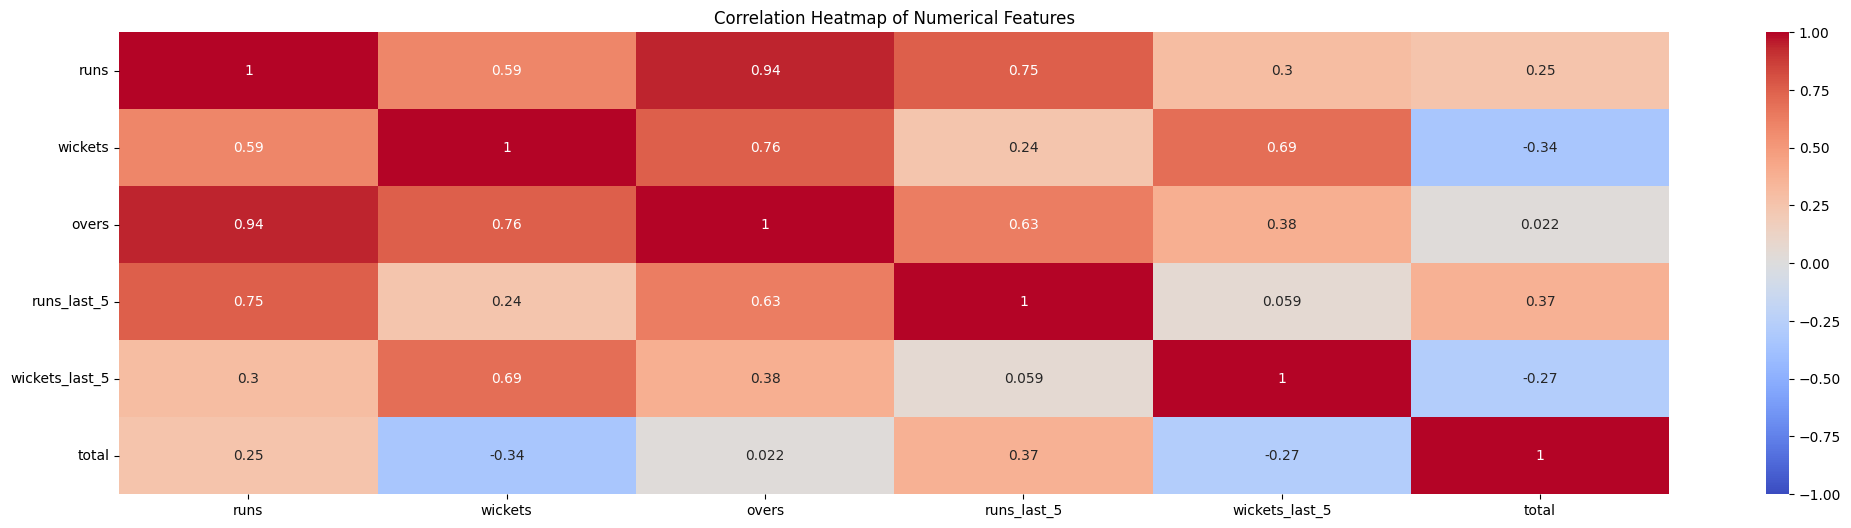

In [20]:
plt.figure(figsize=(25, 6))
numerical_cols = ['runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'total']
correlation = df[numerical_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

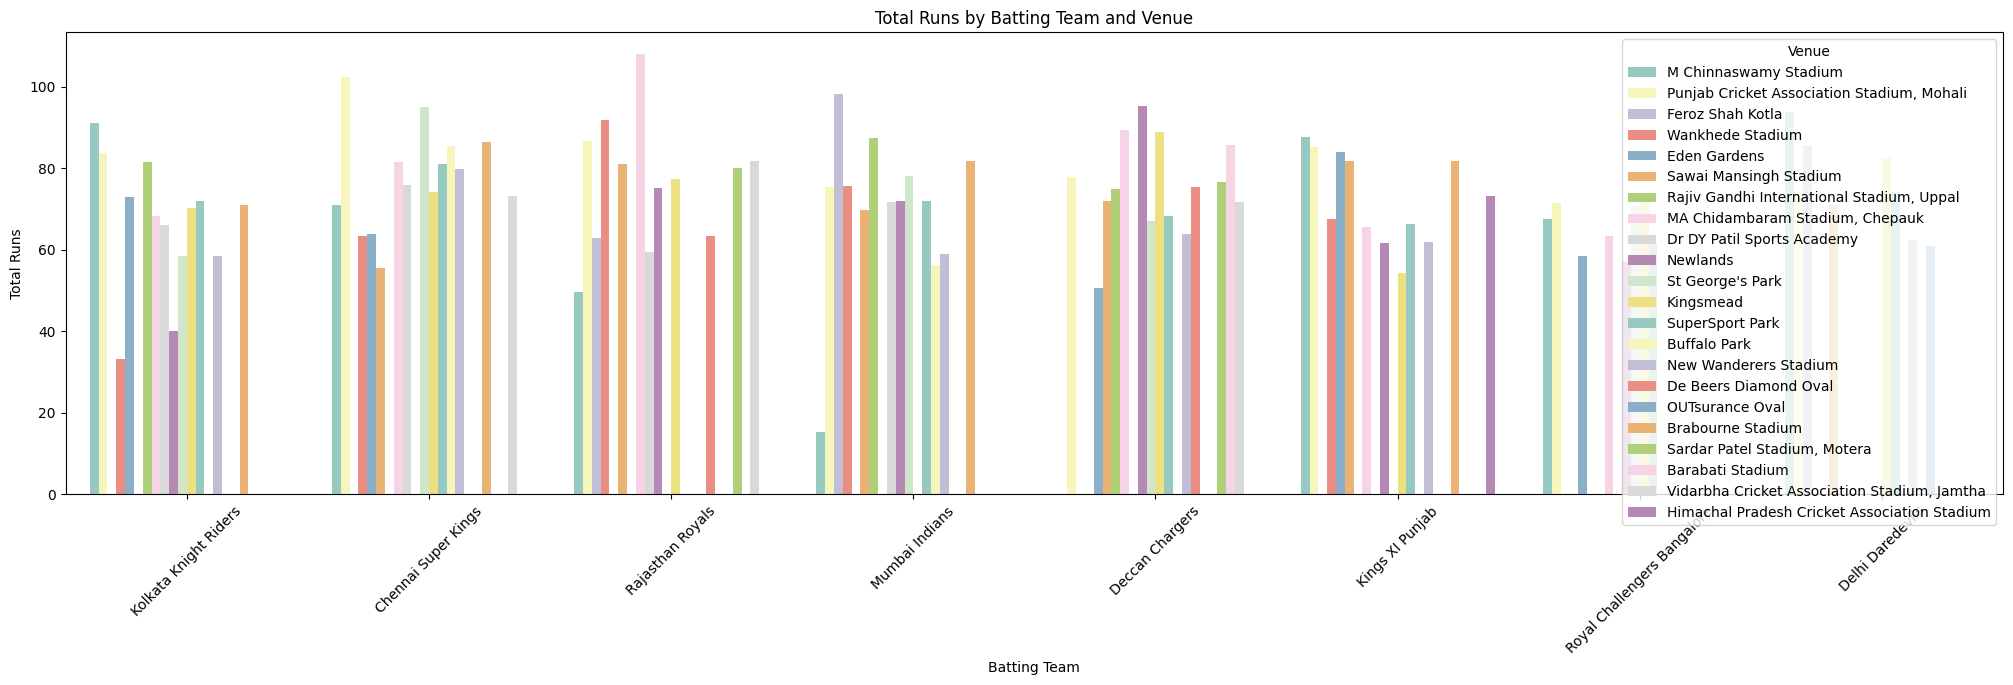

In [21]:
plt.figure(figsize=(25, 6))
sns.barplot(
    data=df[: 20000],
    x='bat_team',
    y='runs',
    hue='venue',
    ci=None,   
    palette='Set3'
)

plt.title('Total Runs by Batting Team and Venue')
plt.xlabel('Batting Team')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.legend(title='Venue')
plt.show()

In [22]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

# Extract day of week (0=Monday, 6=Sunday)
df['day_of_week'] = df['date'].dt.dayofweek

# Extract whether it's a weekend (Saturday/Sunday)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Optional: quarter of the year
df['quarter'] = df['date'].dt.quarter

# Optional: elapsed days since first match
df['days_since_start'] = (df['date'] - df['date'].min()).dt.days

In [23]:
df.drop(columns=["date"],axis=1,inplace=True)

In [24]:
pd.set_option('display.max_columns', None)
pd.set_option("display.max_rows",None)

In [25]:
cols_to_encode = ['venue', 'bat_team', 'bowl_team']
df=pd.get_dummies(df, columns=cols_to_encode, drop_first=True)


In [26]:
bool_cols=df.select_dtypes(include="bool").columns
df[bool_cols]=df[bool_cols].astype(int)

In [27]:
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate
cols=["batsman","bowler"]
mappings={}
le=LabelEncoder()
for col in cols:
    df[col]=le.fit_transform(df[col])
    mappings[col]=dict(zip(le.classes_,le.transform(le.classes_)))


In [28]:
for col, mapping in mappings.items():
    print(f"\nMapping for {col}:")
    print(tabulate(mapping.items(), headers=["Category", "Encoded"],tablefmt="center"))


Mapping for batsman:
Category                Encoded
--------------------  ---------
A Ashish Reddy                0
A Chandila                    1
A Chopra                      2
A Choudhary                   3
A Flintoff                    4
A Kumble                      5
A Mishra                      6
A Mithun                      7
A Mukund                      8
A Nehra                       9
A Singh                      10
A Symonds                    11
A Uniyal                     12
AA Bilakhia                  13
AA Chavan                    14
AA Jhunjhunwala              15
AB Agarkar                   16
AB Dinda                     17
AB McDonald                  18
AB de Villiers               19
AC Blizzard                  20
AC Gilchrist                 21
AC Thomas                    22
AC Voges                     23
AD Mascarenhas               24
AD Mathews                   25
AD Nath                      26
AD Russell                   27
AF Milne          

In [29]:
df.head()

,mid,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total,cumulative_runs,year,month,day,day_of_week,is_weekend,quarter,days_since_start,venue_Brabourne Stadium,venue_Buffalo Park,venue_De Beers Diamond Oval,venue_Dr DY Patil Sports Academy,venue_Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium,venue_Dubai International Cricket Stadium,venue_Eden Gardens,venue_Feroz Shah Kotla,venue_Green Park,venue_Himachal Pradesh Cricket Association Stadium,venue_Holkar Cricket Stadium,venue_JSCA International Stadium Complex,venue_Kingsmead,venue_M Chinnaswamy Stadium,"venue_MA Chidambaram Stadium, Chepauk",venue_Maharashtra Cricket Association Stadium,venue_Nehru Stadium,venue_New Wanderers Stadium,venue_Newlands,venue_OUTsurance Oval,"venue_Punjab Cricket Association IS Bindra Stadium, Mohali","venue_Punjab Cricket Association Stadium, Mohali","venue_Rajiv Gandhi International Stadium, Uppal","venue_Sardar Patel Stadium, Motera",venue_Saurashtra Cricket Association Stadium,venue_Sawai Mansingh Stadium,venue_Shaheed Veer Narayan Singh International Stadium,venue_Sharjah Cricket Stadium,venue_Sheikh Zayed Stadium,venue_St George's Park,venue_Subrata Roy Sahara Stadium,venue_SuperSport Park,"venue_Vidarbha Cricket Association Stadium, Jamtha",venue_Wankhede Stadium,bat_team_Deccan Chargers,bat_team_Delhi Daredevils,bat_team_Gujarat Lions,bat_team_Kings XI Punjab,bat_team_Kochi Tuskers Kerala,bat_team_Kolkata Knight Riders,bat_team_Mumbai Indians,bat_team_Pune Warriors,bat_team_Rajasthan Royals,bat_team_Rising Pune Supergiant,bat_team_Rising Pune Supergiants,bat_team_Royal Challengers Bangalore,bat_team_Sunrisers Hyderabad,bowl_team_Deccan Chargers,bowl_team_Delhi Daredevils,bowl_team_Gujarat Lions,bowl_team_Kings XI Punjab,bowl_team_Kochi Tuskers Kerala,bowl_team_Kolkata Knight Riders,bowl_team_Mumbai Indians,bowl_team_Pune Warriors,bowl_team_Rajasthan Royals,bowl_team_Rising Pune Supergiant,bowl_team_Rising Pune Supergiants,bowl_team_Royal Challengers Bangalore,bowl_team_Sunrisers Hyderabad
0,1,328,201,1,0,0.1,1,0,0,0,222,1,2008,4,18,4,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,61,201,1,0,0.2,1,0,0,0,222,2,2008,4,18,4,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,1,61,201,2,0,0.2,2,0,0,0,222,4,2008,4,18,4,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,1,61,201,2,0,0.3,2,0,0,0,222,6,2008,4,18,4,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,1,61,201,2,0,0.4,2,0,0,0,222,8,2008,4,18,4,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [30]:
from sklearn.feature_selection import SelectKBest, f_regression

X = df.drop('total', axis=1)
y = df['total']

selector = SelectKBest(score_func=f_regression, k=7)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

df = pd.DataFrame(X_new, columns=selected_features)
df['total'] = y.values

In [31]:
df.head()

,runs,wickets,runs_last_5,wickets_last_5,striker,non-striker,cumulative_runs,total
0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,222
1,1.0,0.0,1.0,0.0,0.0,0.0,2.0,222
2,2.0,0.0,2.0,0.0,0.0,0.0,4.0,222
3,2.0,0.0,2.0,0.0,0.0,0.0,6.0,222
4,2.0,0.0,2.0,0.0,0.0,0.0,8.0,222


In [32]:
from sklearn.model_selection import train_test_split

X = df.drop('total', axis=1)
y = df['total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((60811, 7), (15203, 7), (60811,), (15203,))

In [33]:
from tpot import TPOTRegressor
from sklearn.model_selection import RepeatedKFold
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
model= TPOTRegressor(verbosity=2, population_size=10, generations=5, random_state=42,n_jobs=-1,scoring='neg_mean_absolute_error',cv=cv)
model.fit(X_train,y_train)

Version 0.12.1 of tpot is outdated. Version 1.1.0 was released Thursday July 03, 2025.


Optimization Progress:   0%|          | 0/60 [00:00<?, ?pipeline/s]


Generation 1 - Current best internal CV score: -14.149040035907795

Generation 2 - Current best internal CV score: -14.149040035907795

Generation 3 - Current best internal CV score: -14.149040035907795

Generation 4 - Current best internal CV score: -14.149040035907795

Generation 5 - Current best internal CV score: -13.675330112277269

Best pipeline: RandomForestRegressor(input_matrix, bootstrap=False, max_features=0.7500000000000001, min_samples_leaf=11, min_samples_split=18, n_estimators=100)


TPOTRegressor(cv=RepeatedKFold(n_repeats=3, n_splits=5, random_state=42),
              generations=5, n_jobs=-1, population_size=10, random_state=42,
              scoring='neg_mean_absolute_error', verbosity=2)

In [34]:
model.fitted_pipeline_

Pipeline(steps=[('randomforestregressor',
                 RandomForestRegressor(bootstrap=False,
                                       max_features=0.7500000000000001,
                                       min_samples_leaf=11,
                                       min_samples_split=18,
                                       random_state=42))])

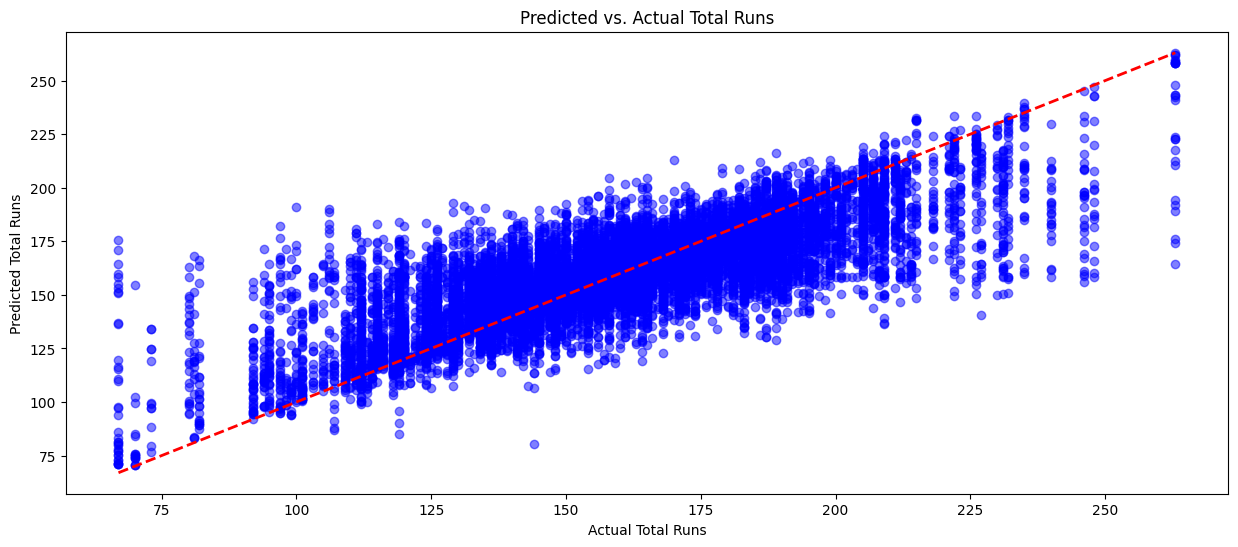

In [35]:
y_pred=model.predict(X_test)
plt.figure(figsize=(15, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Total Runs')
plt.ylabel('Predicted Total Runs')
plt.title('Predicted vs. Actual Total Runs')
plt.show()

In [37]:
from sklearn.metrics import mean_squared_error, r2_score
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")

RMSE: 18.14
R² Score: 0.61


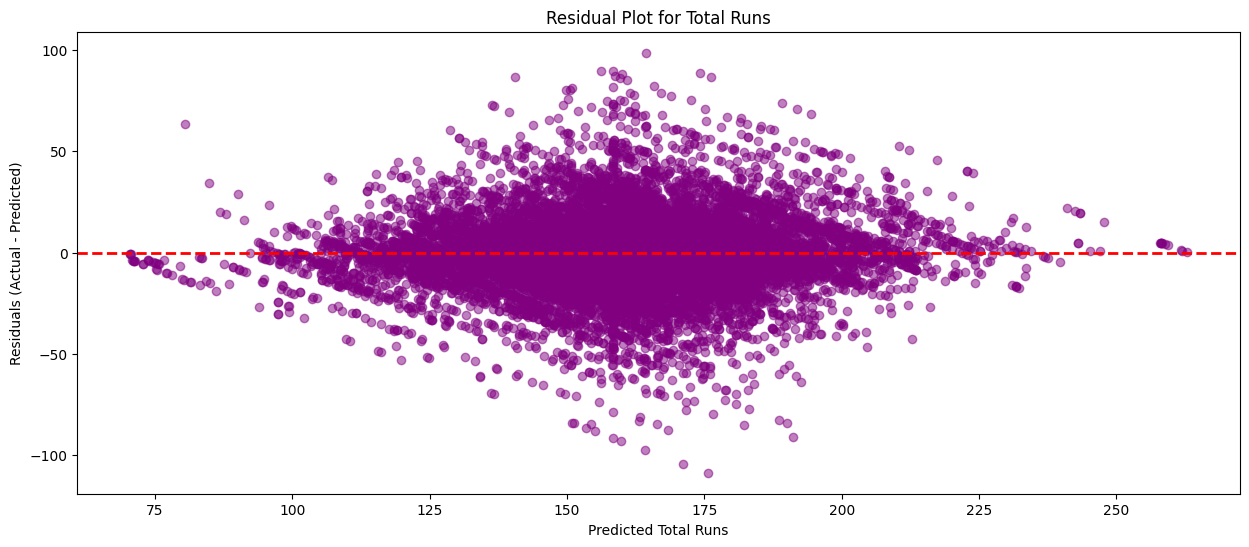

In [39]:
plt.figure(figsize=(15, 6))
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, color='purple', alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Total Runs')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot for Total Runs')
plt.show()

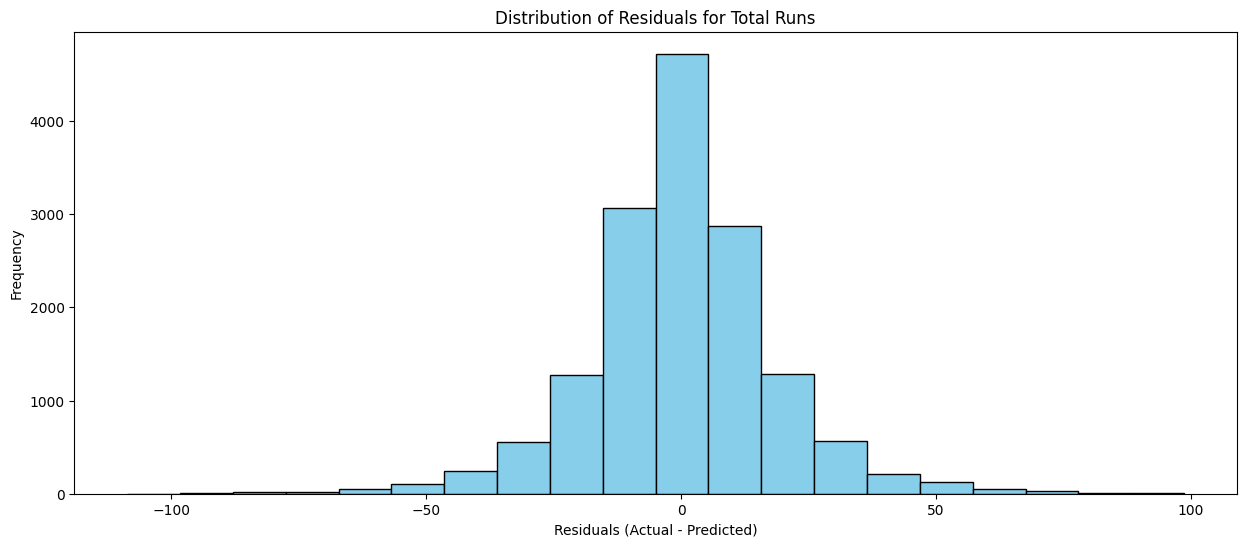

In [40]:
plt.figure(figsize=(15, 6))
plt.hist(residuals, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals for Total Runs')
plt.show()

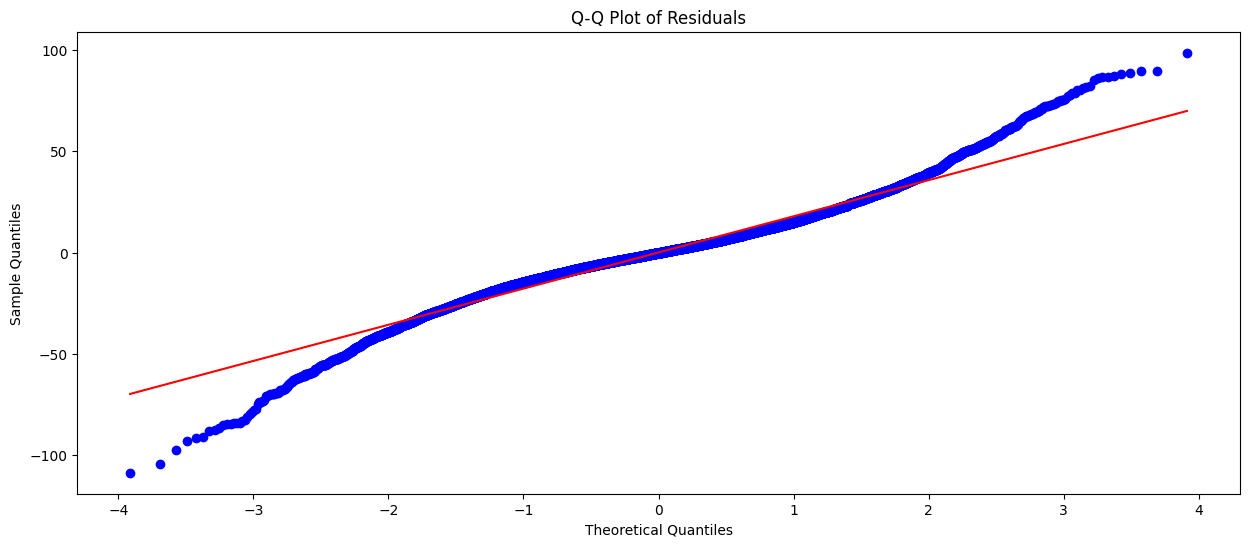

In [42]:
plt.figure(figsize=(15, 6))
from scipy import stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

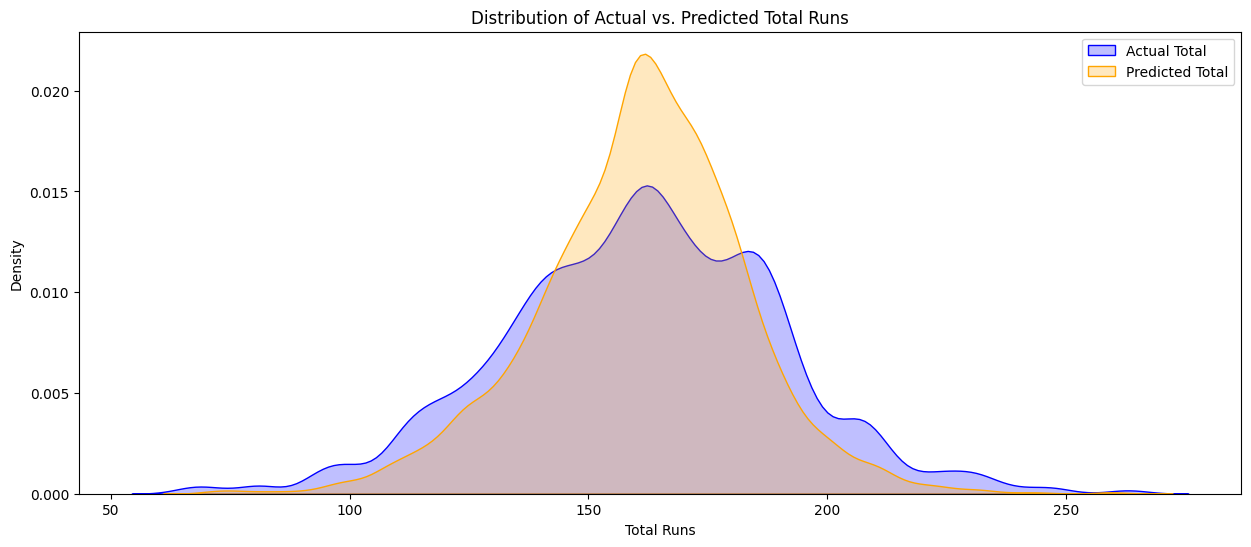

In [43]:
plt.figure(figsize=(15, 6))
sns.kdeplot(y_test, label='Actual Total', color='blue', fill=True)
sns.kdeplot(y_pred, label='Predicted Total', color='orange', fill=True)
plt.xlabel('Total Runs')
plt.ylabel('Density')
plt.title('Distribution of Actual vs. Predicted Total Runs')
plt.legend()
plt.show()

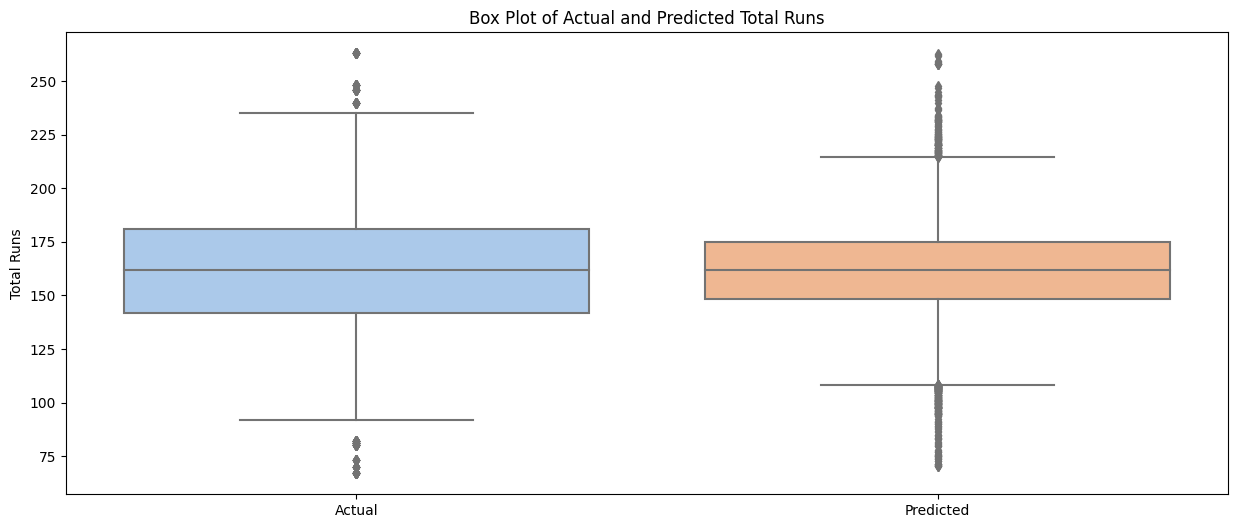

In [44]:
plt.figure(figsize=(15, 6))
data = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
sns.boxplot(data=data, palette='pastel')
plt.title('Box Plot of Actual and Predicted Total Runs')
plt.ylabel('Total Runs')
plt.show()

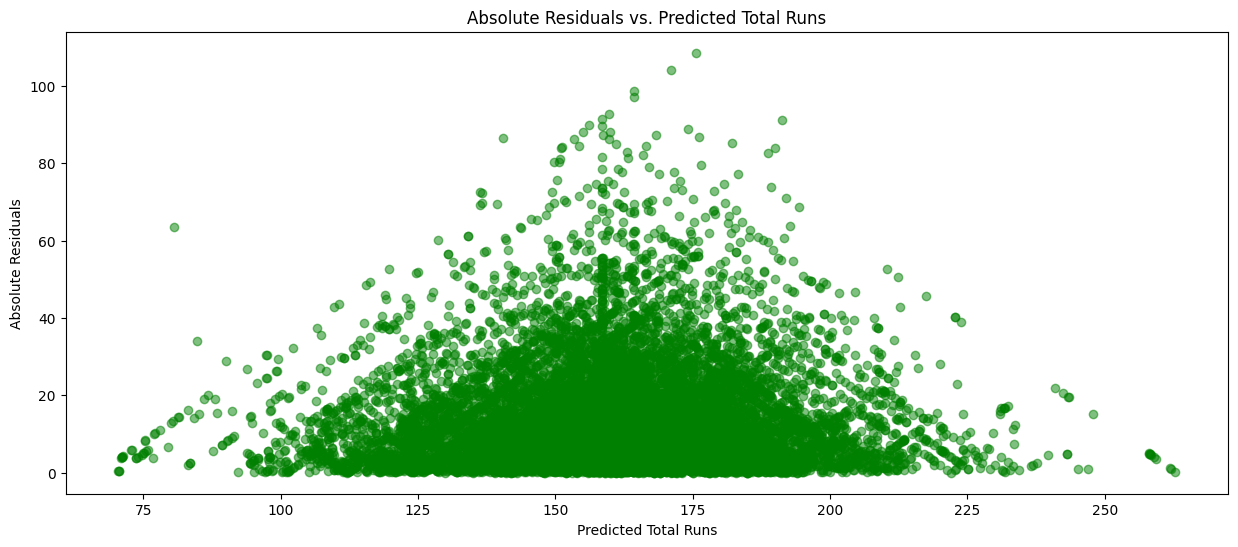

In [45]:
plt.figure(figsize=(15, 6))
plt.scatter(y_pred, np.abs(residuals), color='green', alpha=0.5)
plt.xlabel('Predicted Total Runs')
plt.ylabel('Absolute Residuals')
plt.title('Absolute Residuals vs. Predicted Total Runs')
plt.show()

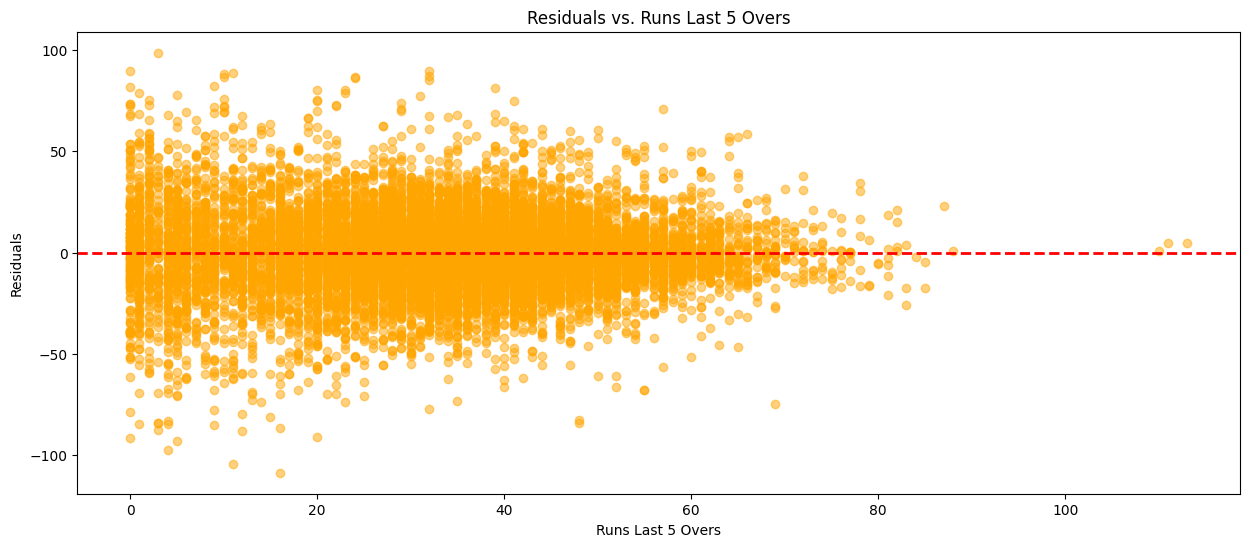

In [46]:
plt.figure(figsize=(15, 6))
if isinstance(X_test, pd.DataFrame) and 'runs_last_5' in X_test.columns:
    feature = X_test['runs_last_5']
    feature_name = 'Runs Last 5 Overs'
else:
    feature = X_test[:, 0]  # Fallback to first feature
    feature_name = 'Feature 0'
plt.scatter(feature, residuals, color='orange', alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel(feature_name)
plt.ylabel('Residuals')
plt.title(f'Residuals vs. {feature_name}')
plt.show()